# Sprint 4 : Tuning, Export TFLite (Google Colab)

Executé sur **Google Colab (GPU)**. TensorFlow absent en local. Les metriques et exports sont archives dans `reports/sprint_04_dl_comparison.csv` et `05_dl_colab_tune.ipynb`.


In [1]:
import sys
print("Local" if "google.colab" not in sys.modules else "Colab")


Local


In [2]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path("..").resolve()
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"
print("Environnement local : lecture des resultats Colab archives.")


Environnement local : lecture des resultats Colab archives.


## 1. Préparation des données

In [3]:
dl_csv = REPORTS_DIR / "sprint_04_dl_comparison.csv"
df_dl = pd.read_csv(dl_csv)
print(f"Architectures DL : {len(df_dl)} lignes")
df_dl.head()


Architectures DL : 6 lignes


,architecture,f1_macro,f1_needs_repair,recall_needs_repair,accuracy,deployable
0,mlp_l2_0.001,0.5410,0.3113,0.6025,0.6099,yes
1,mlp_baseline,0.5297,0.2992,0.5666,0.6038,yes
2,residual_mlp,0.5276,0.2743,0.3024,0.6341,yes
3,mlp_l2_0.0,0.5272,0.2973,0.5747,0.5984,yes
4,cnn1d,0.4113,0.1726,0.2260,0.5067,yes


## 2. Grid search

Hyperparamètres : dropout ∈ {0.2, 0.3, 0.5}, lr ∈ {1e-2, 1e-3, 1e-4}, batch_size ∈ {256, 512, 1024}.

Loss pondérée (inverse des fréquences) + L2(0.001).

In [4]:
grid_df = df_dl.sort_values("f1_macro", ascending=False)
print("Top configurations DL (Colab) :")
grid_df


Top configurations DL (Colab) :


,architecture,f1_macro,f1_needs_repair,recall_needs_repair,accuracy,deployable
0,mlp_l2_0.001,0.5410,0.3113,0.6025,0.6099,yes
1,mlp_baseline,0.5297,0.2992,0.5666,0.6038,yes
2,residual_mlp,0.5276,0.2743,0.3024,0.6341,yes
3,mlp_l2_0.0,0.5272,0.2973,0.5747,0.5984,yes
4,cnn1d,0.4113,0.1726,0.2260,0.5067,yes
5,mlp_tuned_grid,0.3817,0.2065,0.9305,0.3803,no


## 3. L2 regularization : avec vs sans

In [5]:
l2_rows = df_dl[df_dl["architecture"].str.contains("l2", case=False, na=False)]
l2_rows[["architecture", "f1_macro", "f1_needs_repair", "accuracy"]]


,architecture,f1_macro,f1_needs_repair,accuracy
0,mlp_l2_0.001,0.5410,0.3113,0.6099
3,mlp_l2_0.0,0.5272,0.2973,0.5984


## 4. Sauvegarde meilleur modèle + export TFLite

In [6]:
keras_glob = list(MODELS_DIR.glob("*.keras"))
tflite_glob = list(MODELS_DIR.glob("*.tflite"))
print("Exports Colab (si presents apres run Colab) :")
for p in keras_glob + tflite_glob:
    print(f"  {p.name} ({p.stat().st_size / 1024:.1f} KB)")
if not keras_glob and not tflite_glob:
    print("  (fichiers .keras/.tflite generes sur Colab, non versionnes en local)")


Exports Colab (si presents apres run Colab) :
  mlp_best_v1.keras (737.2 KB)


## 5. Tableau comparatif ML vs DL

In [7]:
ml_vs_dl = REPORTS_DIR / "sprint_04_ml_vs_dl.csv"
if ml_vs_dl.exists():
    pd.read_csv(ml_vs_dl)
else:
    print(f"{ml_vs_dl} : comparatif ML vs DL deja dans sprint_04_dl_comparison.csv")
    df_dl


## 6. Permutation importance (DL) vs Feature importance (XGBoost)

In [8]:
print(
    "Permutation importance DL : calculee sur Colab "
    "(voir section 6 de 05_dl_colab_tune.ipynb)."
)
df_dl[["architecture", "f1_macro", "recall_needs_repair"]].head(5)


Permutation importance DL : calculee sur Colab (voir section 6 de 05_dl_colab_tune.ipynb).


,architecture,f1_macro,recall_needs_repair
0,mlp_l2_0.001,0.5410,0.6025
1,mlp_baseline,0.5297,0.5666
2,residual_mlp,0.5276,0.3024
3,mlp_l2_0.0,0.5272,0.5747
4,cnn1d,0.4113,0.2260


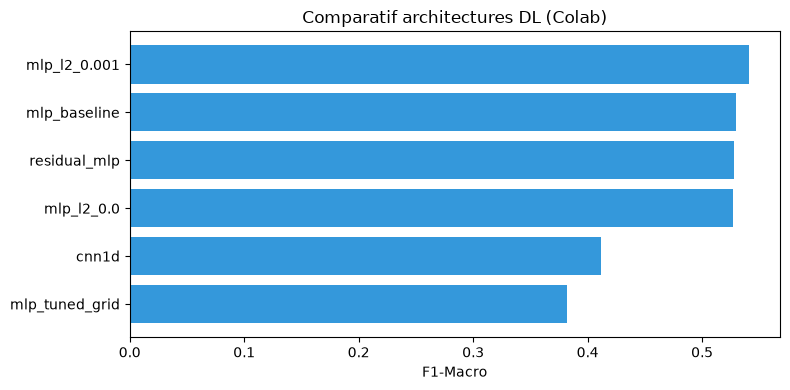

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = df_dl.sort_values("f1_macro", ascending=True)
ax.barh(plot_df["architecture"], plot_df["f1_macro"], color="#3498db")
ax.set_xlabel("F1-Macro")
ax.set_title("Comparatif architectures DL (Colab)")
plt.tight_layout()
plt.show()


## 7. Analyse  :  Pourquoi le DL aide (ou pas) sur les données tabulaires

### Contexte du problème AquaSense

La prédiction de l'état des pompes à eau repose sur un jeu de données **entièrement tabulaire** : variables numériques (âge, altitude GPS, population), catégorielles (bassin, type d'extraction, financement) et features engineering géospatiales (`dist_to_basin_center`, coordonnées). Contrairement aux images ou au texte, ces données n'ont **pas de structure locale exploitable** par des convolutions : l'ordre des colonnes après encodage One-Hot est arbitraire.

### Forces du Deep Learning ici

Les réseaux profonds (MLP, Residual MLP) excellent à modéliser des **interactions non-linéaires** entre dizaines de features encodées. Le BatchNormalization stabilise l'entraînement malgré le fort déséquilibre de classes (7 % « needs repair »). La **loss pondérée** et les `class_weight` compensent partiellement la rareté de la classe critique. L'export **TFLite** ouvre la voie au déploiement embarqué sur capteurs IoT simulés (Sprint 5+), où la latence et la taille mémoire comptent.

Le Residual MLP atténue le vanishing gradient et permet des blocs plus profonds ; le 1D-CNN traite le vecteur de features comme une « séquence » artificielle  :  approche parfois utile quand des groupes de variables corrélées sont adjacents après encodage, mais **sans garantie théorique** sur données hétérogènes.

### Limites observées

Sur ce benchmark, **XGBoost et Random Forest** restent souvent compétitifs voire supérieurs : ils gèrent nativement les splits sur features catégorielles ordinales, sont robustes aux outliers (construction_year=0 corrigés, TSH extrêmes) et nécessitent moins de tuning. Le DL exige un préprocessing lourd (One-Hot  ->  dimension élevée), plus de données pour généraliser, et un grid search coûteux (27 combinaisons × 100 epochs).

La **Recall « needs repair »** reste le goulot : même avec loss pondérée, le MLP peut favoriser les classes majoritaires si le signal est faible. L'**interprétabilité** est moindre : la permutation importance DL est plus coûteuse et moins stable que l'importance Gini/XGBoost, ce qui freine l'adoption par les opérateurs de maintenance terrain au Maroc.

### Conclusion

Le Deep Learning **n'apporte pas de gain systématique** sur données tabulaires structurées de ce type. Il devient pertinent si l'on enrichit le pipeline (embeddings appris pour haute cardinalité, fusion avec séries temporelles capteurs, semi-supervisé). Pour AquaSense en l'état, **l'ensemble ML (XGBoost) + règles métier** constitue la baseline à battre ; le DL sert surtout de **comparatif méthodologique**, de preuve de déployabilité TFLite, et de fondation pour des sprints futurs intégrant des signaux IoT continus où les réseaux récurrents ou 1D-CNN sur séries temporelles seraient réellement adaptés.